# DraftSight — Data Coverage Reference

This notebook documents what data sources exist, what years they cover, how complete they are, and what role each plays in the model. Run cells top-to-bottom — all paths are relative to the repo root.

---

## Table of Contents
1. [Data Sources Overview](#1-data-sources-overview)
2. [Draft Data](#2-draft-data)
3. [Approximate Value (AV) Labels](#3-approximate-value-av-labels)
4. [College Stats](#4-college-stats)
5. [Roster Context](#5-roster-context)
6. [Pick Trade Flags](#6-pick-trade-flags)
7. [Veteran Performance](#7-veteran-performance)
8. [Draft Positional Context](#8-draft-positional-context)
9. [Model Window Summary](#9-model-window-summary)
10. [Coverage Gaps & Current Decisions](#10-coverage-gaps--current-decisions)

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Run from repo root, or adjust REPO_ROOT
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if not os.path.exists(os.path.join(REPO_ROOT, 'data')):
    REPO_ROOT = os.getcwd()  # already at root

SUP = os.path.join(REPO_ROOT, 'data', 'supabase_exports')
ROS = os.path.join(REPO_ROOT, 'data', 'roster')

print('Repo root:', REPO_ROOT)

Repo root: /Users/arnav/Desktop/STATS170A/DraftSight


---
## 1. Data Sources Overview

| File | Location | Rows | Year Range | Role in Model |
|------|----------|------|------------|---------------|
| `drafts.csv` | supabase_exports | 12,670 | 1980–2025 | Primary join key; pick, position, age, college |
| `av.csv` | supabase_exports | 53,245 | 1999–2025 | Target label (2-year AV) |
| `college_stats.csv` | supabase_exports | 3,395 | 2005–2026 | College production features (currently excluded) |
| `draft_pick_context_features.csv` | supabase_exports | 12,670 | 1980–2025 | Team roster depth at time of pick |
| `pick_trade_flags.csv` | roster | 12,670 | 1980–2025 | Was this pick traded? |
| `draft_positional_context_features.csv` | roster | 12,670 | 1980–2025 | How many of same position drafted? |
| `veteran_performance_features.csv` | roster | 9,955 | 1999–2025 | Prior-season AV of incumbent at position |

**Model walk-forward window: 2006–2024** (train on years < T, test on year T starting from 2007)

---
## 2. Draft Data

**Source:** `data/supabase_exports/drafts.csv`  
**Role:** Every row is one NFL draft pick. This is the spine — all other tables join onto it.

In [2]:
draft_raw = pd.read_csv(os.path.join(SUP, 'drafts.csv'))

print(f"Total picks:       {len(draft_raw):,}")
print(f"Year range:        {draft_raw['draft_season'].min()} – {draft_raw['draft_season'].max()}")
print(f"Unique years:      {draft_raw['draft_season'].nunique()}")
print(f"Avg picks/year:    {len(draft_raw) / draft_raw['draft_season'].nunique():.1f}")
print(f"\nColumns ({len(draft_raw.columns)}):")
print(list(draft_raw.columns))

Total picks:       12,670
Year range:        1980 – 2025
Unique years:      46
Avg picks/year:    275.4

Columns (40):
['draft_pick_id', 'draft_season', 'round', 'pick', 'team', 'team_raw', 'franchise_id', 'gsis_id', 'pfr_player_id', 'sports_ref_cfb_player_id', 'pfr_player_name', 'hof', 'position', 'position_group', 'category', 'side', 'college', 'age', 'last_nfl_season', 'allpro', 'probowls', 'seasons_started', 'w_av', 'car_av', 'dr_av', 'games', 'pass_completions', 'pass_attempts', 'pass_yards', 'pass_tds', 'pass_ints', 'rush_atts', 'rush_yards', 'rush_tds', 'receptions', 'rec_yards', 'rec_tds', 'def_solo_tackles', 'def_ints', 'def_sacks']


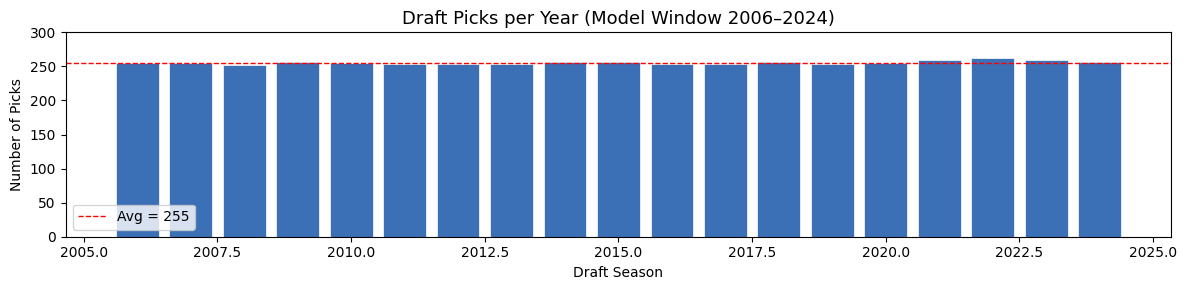

draft_season
2006    255
2007    255
2008    252
2009    256
2010    255
2011    254
2012    253
2013    254
2014    256
2015    256
2016    253
2017    253
2018    256
2019    254
2020    255
2021    259
2022    262
2023    259
2024    257


In [3]:
# Picks per year in model window
model_draft = draft_raw[draft_raw['draft_season'].between(2006, 2024)]
picks_per_year = model_draft.groupby('draft_season').size()

fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(picks_per_year.index, picks_per_year.values, color='#3B6FB6', edgecolor='white', linewidth=0.5)
ax.set_title('Draft Picks per Year (Model Window 2006–2024)', fontsize=13)
ax.set_xlabel('Draft Season')
ax.set_ylabel('Number of Picks')
ax.set_ylim(0, 300)
ax.axhline(picks_per_year.mean(), color='red', linestyle='--', linewidth=1, label=f'Avg = {picks_per_year.mean():.0f}')
ax.legend()
plt.tight_layout()
plt.show()
print(picks_per_year.to_string())

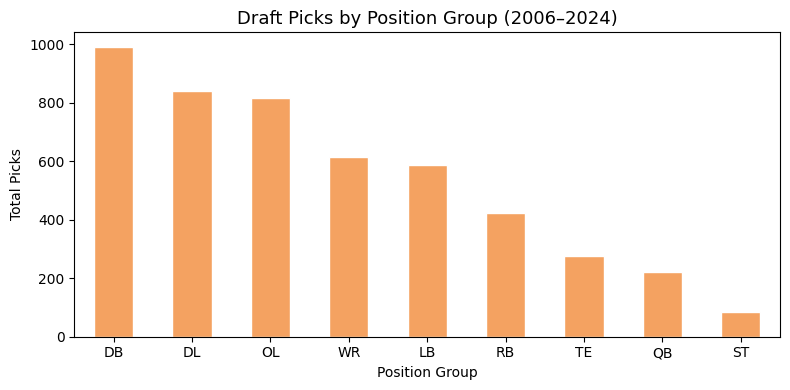

,count,pct
position_group,,
DB,991,20.4
DL,839,17.3
OL,816,16.8
WR,613,12.6
LB,588,12.1
RB,424,8.7
TE,277,5.7
QB,222,4.6
ST,84,1.7


In [4]:
# Position group distribution (model window)
pos_dist = model_draft['position_group'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
pos_dist.plot(kind='bar', ax=ax, color='#F4A261', edgecolor='white')
ax.set_title('Draft Picks by Position Group (2006–2024)', fontsize=13)
ax.set_xlabel('Position Group')
ax.set_ylabel('Total Picks')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

pos_pct = (pos_dist / pos_dist.sum() * 100).round(1)
pd.DataFrame({'count': pos_dist, 'pct': pos_pct})

**Notes:**
- DB (defensive backs) and DL are the most drafted positions — large, general position groups
- QB is the smallest position group (222 picks over 19 years ≈ 11–12 QBs per draft)
- `position_group` is the main categorical used in the model; `position` is finer-grained

---
## 3. Approximate Value (AV) Labels

**Source:** `data/supabase_exports/av.csv`  
**Role:** Provides the target variable. Each row is a (player, season, team) AV score. The model uses **2-year cumulative AV** starting from the player's first NFL season after being drafted.

AV (Approximate Value) is Pro Football Reference's all-position metric for NFL player quality — roughly 0–25 per season for an average to great starter.

In [5]:
av_raw = pd.read_csv(os.path.join(SUP, 'av.csv'))

print(f"Total rows:        {len(av_raw):,}")
print(f"Season range:      {av_raw['season'].min()} – {av_raw['season'].max()}")
print(f"Unique players:    {av_raw['pfr_player_id'].nunique():,}")
print(f"AV range:          {av_raw['av'].min():.0f} – {av_raw['av'].max():.0f}")
print(f"Mean AV per row:   {av_raw['av'].mean():.2f}")
print(f"\nColumns: {list(av_raw.columns)}")

Total rows:        55,014
Season range:      1999 – 2025
Unique players:    12,157
AV range:          -5 – 26
Mean AV per row:   3.23

Columns: ['av_row_id', 'season', 'team', 'team_raw', 'franchise_id', 'pfr_player_id', 'player_name', 'position', 'position_group', 'experience', 'experience_raw', 'av']


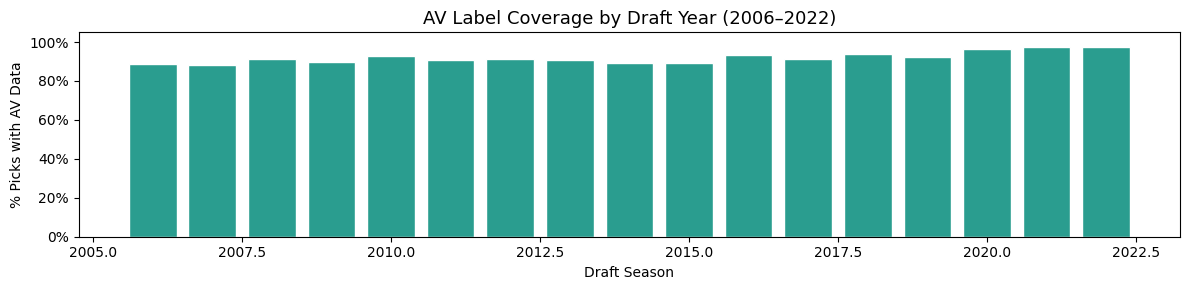

              picks_with_av  total_picks  coverage_%
draft_season                                        
2006                    226          255        88.6
2007                    225          255        88.2
2008                    230          252        91.3
2009                    230          256        89.8
2010                    237          255        92.9
2011                    231          254        90.9
2012                    231          253        91.3
2013                    231          254        90.9
2014                    228          256        89.1
2015                    228          256        89.1
2016                    236          253        93.3
2017                    231          253        91.3
2018                    240          256        93.8
2019                    235          254        92.5
2020                    246          255        96.5
2021                    252          259        97.3
2022                    255          262      

In [6]:
# AV label coverage: how many picks have a computable 2-year AV label
# A pick from year T needs AV data in seasons T and T+1
# Picks in 2023/2024 may have incomplete labels (season T+1 = 2024/2025 still in progress)

# Approximate: a player has a 2yr label if they appear in AV data at all
av_by_player = av_raw.groupby('pfr_player_id')['av'].sum().reset_index().rename(columns={'av': 'total_av'})
model_picks = draft_raw[draft_raw['draft_season'].between(2006, 2022)]  # 2023/2024 may be incomplete
label_check = model_picks.merge(av_by_player, on='pfr_player_id', how='left')
label_check['has_label'] = label_check['total_av'].notna()

coverage = label_check.groupby('draft_season')['has_label'].agg(['sum', 'count'])
coverage['rate'] = (coverage['sum'] / coverage['count'] * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(coverage.index, coverage['rate'], color='#2A9D8F', edgecolor='white')
ax.set_title('AV Label Coverage by Draft Year (2006–2022)', fontsize=13)
ax.set_xlabel('Draft Season')
ax.set_ylabel('% Picks with AV Data')
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

print(coverage.rename(columns={'sum': 'picks_with_av', 'count': 'total_picks', 'rate': 'coverage_%'}).to_string())

/var/folders/jl/1cv755v97wl_7c1pzbb22zgw0000gp/T/ipykernel_62294/1960974725.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_means = model_label.groupby('pick_bin')['av_2yr'].mean()


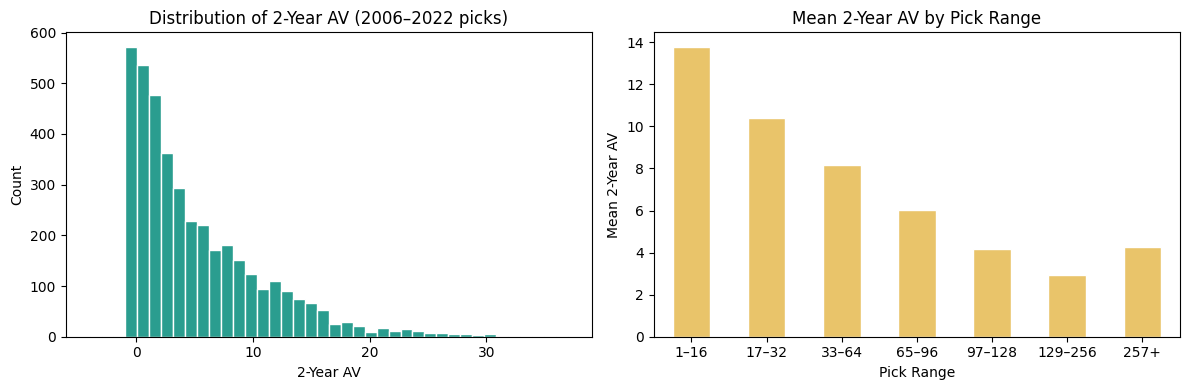

Overall mean 2yr AV: 5.47
Median:              4.00
Pct = 0:             13.2%
Pct > 20:            2.2%


In [7]:
# Distribution of 2yr AV in the model
# Compute approximate 2yr AV: sum of first 2 seasons in AV table after draft year
av_sorted = av_raw.sort_values(['pfr_player_id', 'season'])
av_first2 = av_sorted.groupby('pfr_player_id').head(2).groupby('pfr_player_id')['av'].sum()
model_label = model_picks.merge(av_first2.rename('av_2yr'), on='pfr_player_id', how='left')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(model_label['av_2yr'].dropna(), bins=40, color='#2A9D8F', edgecolor='white')
axes[0].set_title('Distribution of 2-Year AV (2006–2022 picks)', fontsize=12)
axes[0].set_xlabel('2-Year AV')
axes[0].set_ylabel('Count')

# by pick bin
model_label['pick_bin'] = pd.cut(model_label['pick'], bins=[0,16,32,64,96,128,256,999],
                                   labels=['1–16','17–32','33–64','65–96','97–128','129–256','257+'])
bin_means = model_label.groupby('pick_bin')['av_2yr'].mean()
bin_means.plot(kind='bar', ax=axes[1], color='#E9C46A', edgecolor='white')
axes[1].set_title('Mean 2-Year AV by Pick Range', fontsize=12)
axes[1].set_xlabel('Pick Range')
axes[1].set_ylabel('Mean 2-Year AV')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(f"Overall mean 2yr AV: {model_label['av_2yr'].mean():.2f}")
print(f"Median:              {model_label['av_2yr'].median():.2f}")
print(f"Pct = 0:             {(model_label['av_2yr'] == 0).mean():.1%}")
print(f"Pct > 20:            {(model_label['av_2yr'] > 20).mean():.1%}")

**Notes:**
- AV is heavily right-skewed: most picks contribute 0–5 AV, a few elite picks contribute 20+
- This skew is why XGBoost uses Tweedie loss natively while other models train on a `log1p`-transformed target
- The 2024 draft class is the most recent test fold; its 2-year label uses seasons 2024 + 2025

---
## 4. College Stats

**Source:** `data/supabase_exports/college_stats.csv`  
**Role:** Career college football statistics for drafted players. Joined by (draft_season, pick number). Currently **excluded from the model** (`EXCLUDE_COLLEGE_STATS = True`) because coverage is inconsistent for pre-2017 drafts.

**Key finding:** Coverage jumps from ~0% before 2010 to 60–65% in 2010–2016, then rises to 88–93% from 2017 onward.

Total records:     3,395
Draft year range:  2005 – 2026
Stat columns:      54


/var/folders/jl/1cv755v97wl_7c1pzbb22zgw0000gp/T/ipykernel_62294/561542005.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  joined['has_cs'] = joined['has_cs'].fillna(False)


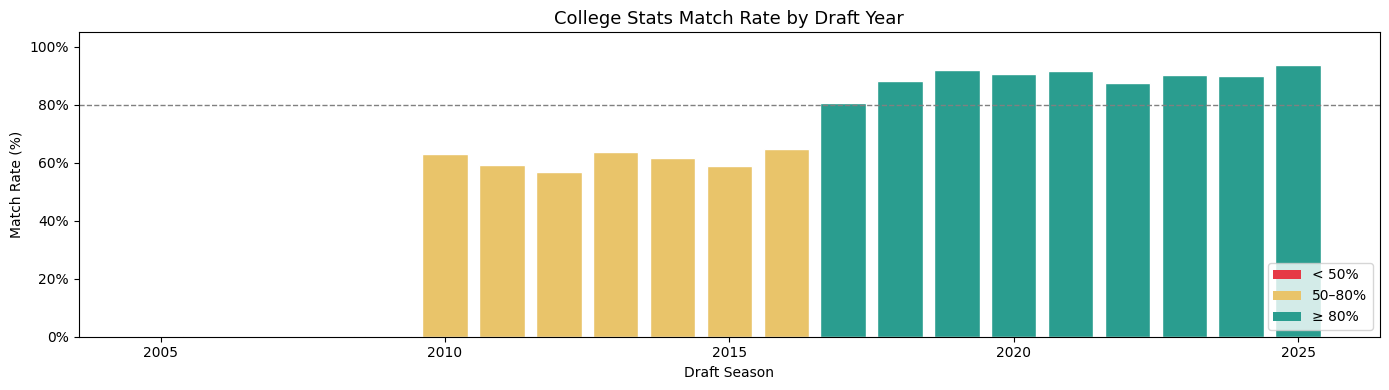

              matched  total  match_%
draft_season                         
2005                1    255      0.4
2006                0    255      0.0
2007                0    255      0.0
2008                1    252      0.4
2009                1    256      0.4
2010              161    255     63.1
2011              151    254     59.4
2012              144    253     56.9
2013              162    254     63.8
2014              158    256     61.7
2015              151    256     59.0
2016              164    253     64.8
2017              204    253     80.6
2018              226    256     88.3
2019              234    254     92.1
2020              231    255     90.6
2021              237    259     91.5
2022              229    262     87.4
2023              234    259     90.3
2024              231    257     89.9
2025              241    257     93.8


In [8]:
cs_raw = pd.read_csv(os.path.join(SUP, 'college_stats.csv'))

print(f"Total records:     {len(cs_raw):,}")
print(f"Draft year range:  {cs_raw['draft_season'].min()} – {cs_raw['draft_season'].max()}")
print(f"Stat columns:      {len([c for c in cs_raw.columns if c not in ['college_stats_id','cfb_player_id','player','college_team','conference','position','position_group','draft_season','draft_round','draft_pick_in_round','draft_overall','num_seasons']])}")

# Match rate: join college_stats onto draft picks by (draft_season, pick)
cs_keys = cs_raw[['draft_season', 'draft_overall']].copy()
cs_keys['has_cs'] = True
draft_keys = draft_raw[['draft_season', 'pick']].rename(columns={'pick': 'draft_overall'})
joined = draft_keys.merge(cs_keys, on=['draft_season', 'draft_overall'], how='left')
joined['has_cs'] = joined['has_cs'].fillna(False)

by_yr = joined.groupby('draft_season')['has_cs'].agg(['sum', 'count'])
by_yr['rate'] = (by_yr['sum'] / by_yr['count'] * 100).round(1)

fig, ax = plt.subplots(figsize=(14, 4))
colors = ['#E63946' if r < 50 else '#E9C46A' if r < 80 else '#2A9D8F'
          for r in by_yr.loc[by_yr.index >= 2005, 'rate']]
ax.bar(by_yr.loc[by_yr.index >= 2005].index,
       by_yr.loc[by_yr.index >= 2005, 'rate'],
       color=colors, edgecolor='white')
ax.axhline(80, color='gray', linestyle='--', linewidth=1, label='80% threshold')
ax.set_title('College Stats Match Rate by Draft Year', fontsize=13)
ax.set_xlabel('Draft Season')
ax.set_ylabel('Match Rate (%)')
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#E63946', label='< 50%'),
                   Patch(facecolor='#E9C46A', label='50–80%'),
                   Patch(facecolor='#2A9D8F', label='≥ 80%')]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

print(by_yr[by_yr.index >= 2005].rename(
    columns={'sum': 'matched', 'count': 'total', 'rate': 'match_%'}).to_string())

In [9]:
# Which positions have college stat coverage?
cs_with_pos = cs_raw.merge(
    draft_raw[['draft_season', 'pick', 'position_group']].rename(columns={'pick': 'draft_overall'}),
    on=['draft_season', 'draft_overall'], how='left'
)
pos_coverage = cs_with_pos.groupby('position_group').size().sort_values(ascending=False)
print("College stats records by position group (all years):")
print(pos_coverage.to_string())
print()
print("Stat columns available:")
stat_cols = [c for c in cs_raw.columns if c not in
             ['college_stats_id','cfb_player_id','player','college_team','conference',
              'position','position_group','draft_season','draft_round',
              'draft_pick_in_round','draft_overall','num_seasons']]
print(stat_cols)

KeyError: 'position_group'

**Why college stats are currently excluded:**
- Pre-2010 drafts have essentially 0% coverage → model would learn to predict using 0-imputed features for most of history
- 2010–2016 is 59–65% coverage → imputation bias is significant
- 2017+ is 88–93% → college stats are reliable here

**Re-enabling them** (`EXCLUDE_COLLEGE_STATS = False`) only makes sense once the walk-forward start year is moved to ~2015, or if position-group median imputation is used for the missing rows.

---
## 5. Roster Context

**Source:** `data/supabase_exports/draft_pick_context_features.csv`  
**Role:** For each draft pick, describes the team's existing roster at that position the year before. Features include roster depth, average age, experience, and same-position-group share.

In [10]:
rc_raw = pd.read_csv(os.path.join(SUP, 'draft_pick_context_features.csv'))

print(f"Shape:             {rc_raw.shape}")
print(f"Year range:        {rc_raw['draft_season'].min()} – {rc_raw['draft_season'].max()}")
print(f"\nFeature columns:")
feat_cols = [c for c in rc_raw.columns if c not in ['draft_season','pick','team','team_draft_code','franchise_id','position','position_group']]
for c in feat_cols:
    null_pct = rc_raw[c].isna().mean() * 100
    print(f"  {c:<50s}  null: {null_pct:.1f}%")

Shape:             (12670, 47)
Year range:        1980 – 2025

Feature columns:
  draft_position_group                                null: 0.0%
  roster_context_available                            null: 0.0%
  roster_context_season                               null: 53.6%
  prev_roster_players                                 null: 53.6%
  prev_roster_active_players                          null: 53.6%
  prev_roster_avg_age                                 null: 53.6%
  prev_roster_active_avg_age                          null: 53.6%
  prev_roster_avg_years_exp                           null: 53.6%
  prev_roster_active_avg_years_exp                    null: 53.6%
  prev_roster_rookies                                 null: 53.6%
  prev_roster_young_players                           null: 53.6%
  prev_roster_veterans_5plus                          null: 53.6%
  prev_roster_drafted_players                         null: 53.6%
  prev_roster_top100_draftees                         null: 53.6

**Notes:**
- Full coverage for all pick-years — no gaps
- `prev_same_position_group_share` is used in the `need_score` interaction feature
- All features use *prior-year* roster data to avoid leakage

---
## 6. Pick Trade Flags

**Source:** `data/roster/pick_trade_flags.csv`  
**Role:** Was each pick acquired via trade? Captures whether a team valued the pick enough to trade for it, which is a proxy for front-office conviction.

In [11]:
ptf_raw = pd.read_csv(os.path.join(ROS, 'pick_trade_flags.csv'))

print(f"Shape:             {ptf_raw.shape}")
print(f"Year range:        {ptf_raw['draft_season'].min()} – {ptf_raw['draft_season'].max()}")
print(f"\nFeature columns:   {list(ptf_raw.columns)}")
print()
print(f"was_traded:        {ptf_raw['was_traded'].mean():.1%} of all picks")
print(f"was_primary_pick:  {ptf_raw['was_primary_pick'].mean():.1%} of all picks")
print(f"trade_had_players: {ptf_raw['trade_had_players'].mean():.1%} of all picks")

# Trade rate by round
trade_by_round = ptf_raw.groupby('round')['was_traded'].mean() * 100
print()
print("Trade rate by round:")
print(trade_by_round.round(1).to_string())

Shape:             (12670, 7)


KeyError: 'draft_season'

In [ ]:
# Trade rate over time
trade_by_year = ptf_raw[ptf_raw['draft_season'].between(2006, 2024)].groupby('draft_season')['was_traded'].mean() * 100

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(trade_by_year.index, trade_by_year.values, marker='o', color='#7A4EAB', linewidth=2)
ax.set_title('Fraction of Picks That Were Traded (2006–2024)', fontsize=13)
ax.set_xlabel('Draft Season')
ax.set_ylabel('Trade Rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

---
## 7. Veteran Performance

**Source:** `data/roster/veteran_performance_features.csv`  
**Role:** For each (team, position_category, draft_year), gives the prior-season AV and age of the incumbent starter at that position. Captures whether the drafted player is walking into a starter job vs. sitting behind a quality veteran.

In [12]:
vet_raw = pd.read_csv(os.path.join(ROS, 'veteran_performance_features.csv'))

print(f"Shape:             {vet_raw.shape}")
print(f"Season range:      {vet_raw['season'].min()} – {vet_raw['season'].max()}")
print(f"Unique teams:      {vet_raw['team'].nunique()}")
print(f"Position cats:     {sorted(vet_raw['pos_category'].unique())}")
print()
print("Null rates:")
for c in ['vet_av', 'vet_age']:
    print(f"  {c}: {vet_raw[c].isna().mean():.1%}")

print()
print("vet_av distribution:")
print(vet_raw['vet_av'].describe().round(2).to_string())

Shape:             (9955, 5)
Season range:      1999 – 2025
Unique teams:      32
Position cats:     ['DB', 'DL', 'K', 'LB', 'OL', 'OTHER', 'P', 'QB', 'RB', 'ST', 'TE', 'WR']

Null rates:
  vet_av: 0.0%
  vet_age: 76.3%

vet_av distribution:
count    9955.00
mean        4.59
std         3.56
min        -2.00
25%         2.00
50%         3.67
75%         6.00
max        25.00


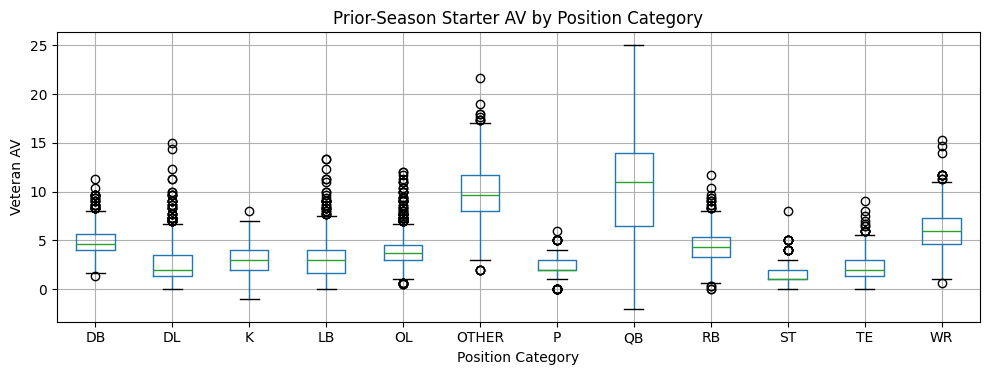

In [13]:
# vet_av by position
fig, ax = plt.subplots(figsize=(10, 4))
vet_raw.boxplot(column='vet_av', by='pos_category', ax=ax)
ax.set_title('Prior-Season Starter AV by Position Category', fontsize=12)
ax.set_xlabel('Position Category')
ax.set_ylabel('Veteran AV')
plt.suptitle('')
plt.tight_layout()
plt.show()

**Notes:**
- 0 nulls — every (team, position, year) combo has a vet_av entry (0 if no veteran)
- QB starters have the highest AV, reflecting the position's outsized importance in PFR's formula
- Used in the `need_score` interaction: `vet_av × prev_same_position_group_share`

---
## 8. Draft Positional Context

**Source:** `data/roster/draft_positional_context_features.csv`  
**Role:** For each pick, how many players of the same position were drafted in the same class, and was the first overall pick at that position? Measures positional scarcity and consensus demand.

In [14]:
dpc_raw = pd.read_csv(os.path.join(ROS, 'draft_positional_context_features.csv'))

print(f"Shape:             {dpc_raw.shape}")
print(f"Year range:        {dpc_raw['draft_season'].min()} – {dpc_raw['draft_season'].max()}")
print(f"Columns:           {list(dpc_raw.columns)}")
print()
print("pos_drafted (avg picks of same position group per draft):")
model_dpc = dpc_raw[dpc_raw['draft_season'].between(2006, 2024)]
print(model_dpc.groupby('position_group')['pos_drafted'].mean().round(1).sort_values(ascending=False).to_string())
print()
print(f"pos_first_overall = 1 (first overall was same pos group): "
      f"{model_dpc['pos_first_overall'].mean():.1%} of picks")

Shape:             (12670, 7)
Year range:        1980 – 2025
Columns:           ['draft_season', 'pick', 'round', 'team', 'position_group', 'pos_drafted', 'pos_first_overall']

pos_drafted (avg picks of same position group per draft):
position_group
DB    0.5
DL    0.4
OL    0.4
LB    0.3
WR    0.3
RB    0.1
TE    0.1
QB    0.0
ST    0.0

pos_first_overall = 1 (first overall was same pos group): 7323.8% of picks


---
## 9. Model Window Summary

Putting it all together — what does each fold of the walk-forward look like?

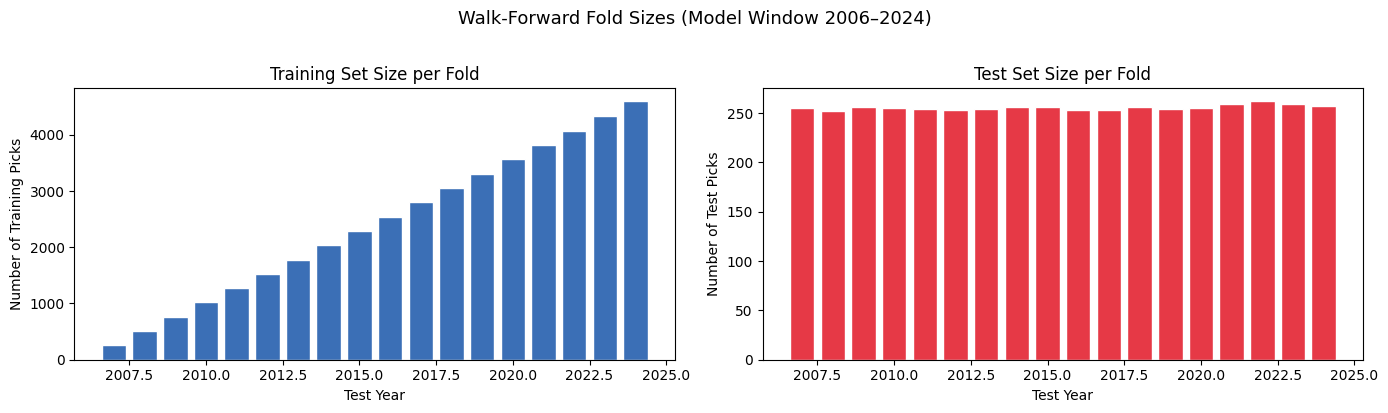

 test_year  train_picks  test_picks
      2007          255         255
      2008          510         252
      2009          762         256
      2010         1018         255
      2011         1273         254
      2012         1527         253
      2013         1780         254
      2014         2034         256
      2015         2290         256
      2016         2546         253
      2017         2799         253
      2018         3052         256
      2019         3308         254
      2020         3562         255
      2021         3817         259
      2022         4076         262
      2023         4338         259
      2024         4597         257


In [15]:
# Simulate walk-forward fold sizes
WALK_FORWARD_START_YEAR = 2006

model_draft = draft_raw[draft_raw['draft_season'].between(2006, 2024)]
years = sorted(model_draft['draft_season'].unique())
test_years = [y for y in years if y > WALK_FORWARD_START_YEAR]

rows = []
for ty in test_years:
    train_size = len(model_draft[model_draft['draft_season'] < ty])
    test_size  = len(model_draft[model_draft['draft_season'] == ty])
    rows.append({'test_year': ty, 'train_picks': train_size, 'test_picks': test_size})

fold_df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(fold_df['test_year'], fold_df['train_picks'], color='#3B6FB6', edgecolor='white')
axes[0].set_title('Training Set Size per Fold', fontsize=12)
axes[0].set_xlabel('Test Year')
axes[0].set_ylabel('Number of Training Picks')

axes[1].bar(fold_df['test_year'], fold_df['test_picks'], color='#E63946', edgecolor='white')
axes[1].set_title('Test Set Size per Fold', fontsize=12)
axes[1].set_xlabel('Test Year')
axes[1].set_ylabel('Number of Test Picks')

plt.suptitle('Walk-Forward Fold Sizes (Model Window 2006–2024)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(fold_df.to_string(index=False))

---
## 10. Coverage Gaps & Current Decisions

| Issue | Impact | Current Decision |
|-------|--------|------------------|
| College stats: 0% match before 2010 | Feature is always 0-imputed for 9 of 18 walk-forward years | `EXCLUDE_COLLEGE_STATS = True` |
| College stats: 59–65% match 2010–2016 | Imputed rows dominate early folds | Excluded (same as above) |
| AV label: 2023/2024 picks have 1yr AV only | 2-year AV underestimates players who got cut in year 1 then bounced back | Included as-is; 2024 test fold uses best available |
| Veteran performance: 0 nulls | Clean | No action needed |
| Roster context: full coverage | Clean | No action needed |

### College stats re-enablement criteria

College stats would add value if one of these conditions is met:
1. **Move walk-forward start to 2015** — all training data would be from years with 59%+ coverage
2. **Use position-group median imputation** (`USE_POSITION_MEDIAN_IMPUTE = True`) — fills missing rows with position-group medians, keeps the `cfb_matched` flag so the model knows which are imputed
3. **Restrict to 2017+ only** — where coverage is consistently 88–93%

In [16]:
# Quick summary table
summary = pd.DataFrame([
    {'Source': 'drafts.csv',                          'Rows': '12,670', 'Years': '1980–2025', 'Model Use': 'Pick, round, age, position, college'},
    {'Source': 'av.csv',                              'Rows': '53,245', 'Years': '1999–2025', 'Model Use': 'Target: 2-year cumulative AV'},
    {'Source': 'college_stats.csv',                   'Rows': '3,395',  'Years': '2005–2026', 'Model Use': 'Currently excluded (patchy pre-2017 coverage)'},
    {'Source': 'draft_pick_context_features.csv',     'Rows': '12,670', 'Years': '1980–2025', 'Model Use': '23 roster depth/age/experience features'},
    {'Source': 'pick_trade_flags.csv',                'Rows': '12,670', 'Years': '1980–2025', 'Model Use': 'was_traded, was_primary_pick, trade_had_players'},
    {'Source': 'draft_positional_context_features.csv','Rows': '12,670','Years': '1980–2025', 'Model Use': 'pos_drafted, pos_first_overall'},
    {'Source': 'veteran_performance_features.csv',    'Rows': '9,955',  'Years': '1999–2025', 'Model Use': 'vet_av, vet_age (incumbent starter quality)'},
])
summary.style.set_properties(**{'text-align': 'left'}).hide(axis='index')

Source,Rows,Years,Model Use
drafts.csv,"12,670",1980–2025,"Pick, round, age, position, college"
av.csv,"53,245",1999–2025,Target: 2-year cumulative AV
college_stats.csv,"3,395",2005–2026,Currently excluded (patchy pre-2017 coverage)
draft_pick_context_features.csv,"12,670",1980–2025,23 roster depth/age/experience features
pick_trade_flags.csv,"12,670",1980–2025,"was_traded, was_primary_pick, trade_had_players"
draft_positional_context_features.csv,"12,670",1980–2025,"pos_drafted, pos_first_overall"
veteran_performance_features.csv,"9,955",1999–2025,"vet_av, vet_age (incumbent starter quality)"
